In [137]:
using LinearAlgebra
using Plots
using Printf

## Questão 2 )



### Letra a)

Pelo exercício 1, dado $m \geq  d + 1$, podemos garantir que $L_X$ possui posto completo, o que implica que $L_X$ é uma transformação injetiva. Ou seja, garantimos que suas inversas são inversas à esquerda. 

Sabemos que "$R_{X,d} \circ L_X = id_\mathcal{P_d}$ somente se $R_{X,d} \circ L_X(p) = p$ para todo $p \in \mathcal{P_d}$"

Pela definição, sabemos que $R_{X,d}(L_X(p)) = \argmin_{q \in \mathcal{P}_d}\|L_X(q) - L_X(p)\|^2_2$. Isso é minimizado quando $$\|L_X(q) - L_X(p)\|^2_2 = 0$$, o que acontece quando $L_X(q) = L_X(p)$. Porém, como $L_X$ é injetiva, $p = q$. Assim, para todo $p \in \mathcal{P_d}$, $R_{X,d} \circ L_X(p) = p$ provando que $R_{X,d}$ é inversa à esquerda de $L_X$.



### Letra b)

Sabemos que $m \geq d + 1$, o que implica que a matriz de $L_X$ terá dimensões $m \times (d+1)$. Seja A a matriz associada a $L_X$, o problema $R_{X,d}(L_X(p)) = p$, com $L_x(p) = b$ é por definiçaõ o problema de mínimos qudrados. Dessa forma, envolve encontrar 

$$ Ap = b \rightarrow A^TAp = A^Tb \rightarrow p = (A^TA)^{-1}A^Tb$$

Como $A$ tem posto completo, o que garantimos pelo exercício 1, então $A^TA$ também, e portanto $A^TA$ é quadrada e inversível. Assim $R_{X,d}(b) = (A^TA)^{-1}A^Tb$ é uma aplicação de uma matriz sobre um vetor, o que é uma transformação linear.

### Letra c)

Sabemos que na base canônica de $\mathcal{P_d}$, $\lbrace 1, x, x^2 \dots x^d \rbrace$, nossa matriz $L_X$ se torna a matriz de Vandermonde retangular, já que sabemos que $m \geq d + 1$.


$$ \textit{Matriz de Vandermonde (V)} :
\begin{bmatrix}
1 & x_1 & x_1^2 & \dots & x_1^d \\
1 & x_2 & x_2^2 & \dots & x_2^d \\
\vdots & \vdots & \vdots & \vdots & \vdots \\
1 & x_m & x_m^2 & \dots & x_m^d 
\end{bmatrix}
$$

Como vimos no item $b$, a solução de mínimos quadrados é $p = (A^TA)^{-1}A^Tb$. Portanto, podemos calcular $R_{X,d}$ como a pseudo-inversa de $L_x$. Assim,

$$ R_{X,d} = (V^TV)^{-1}V^T$$

é a matriz associada a $R_{X,d}$ na base canônica de $\mathcal{P}_d$. 


### Letra d )

A questão pede para escolhermos alguns valores de $m =$ #$X$ e $d$ e estudar qual o comportamento do condicionamento de $L_X$ e $R_{X,d}$ na base canônica $\mathcal{P_d}$, ou seja, $L_X$ é uma matriz de Vandermonde retangular e $R_{X,d}$ sua pseudo-inversa, quando $m$ e/ou $d$ aumentam.

Primeiramente, vamos provar que o condicionamento das matrizes associadas a $L_X$ e $R_{X,d}$ é igual. Seja A a matriz associada a $L_X$ então a matriz associada a $R_{X,d}$ é a pseudo-inversa de A. Por definição, o condicionamento de uma matriz retangular com $m \geq n$ e posto completo é definido em termos da sua pseudo-inversa, logo, igual a norma da $A$ vezes a norma da sua pseudo-inversa.

$$ \kappa (A) = \| A \| \|A^+\|$$

Seja $A = \hat{U} \hat{\Sigma} V^T$ a SVD reduzida de $A$, então a SVD reduzida de $A^+$ é $A^+A = I \rightarrow A^+\hat{U} \hat{\Sigma} V^T = I \rightarrow A^+ = V \hat{\Sigma}^{-1} \hat{U}^T$.

Portanto, o maior valor singular de $A$ é $\sigma_1$ e o menor é $\sigma_{d+1}$, e os de $A^+$ são $\frac{1}{\sigma_{d+1}}$ e $\frac{1}{\sigma_1}$.

Dessa forma, sabemos também que o condicionamento de uma matriz quando utilizado a norma 2 pode ser expresso como

$$ \kappa (A) = \frac{\sigma_{máx}}{\sigma_{mín}}$$

Logo, $\kappa (A) = \kappa (A^+) = \frac{\sigma_{1}}{\sigma_{d+1}}$.

Apesar disso, nesse curso, já percebemos que algumas coisas, às vezes, não se comportam da forma que queremos, portanto, vamos testar o que acontece com a pseudo-inversa também.

In [88]:
function createVandermonde(vetor, d)
    Vandermonde = vetor .^ (0:d)'
    return Vandermonde
end    

function evalConditionVandermonde(m, d; inversa= false)
    vetor = LinRange(-1,1,m)
    V = createVandermonde(vetor, d)
    if inversa
        return(cond(pinv(V)))
    else
        return cond(V)
    end
end

evalConditionVandermonde (generic function with 1 method)

In [89]:
function plot_condition_evaluated(m, d; variate_m = true, variate_d = false, logscale= false)
    if variate_m && !variate_d
        x = (d+1):100:m
        y = [evalConditionVandermonde(i, d) for i in x]
        y_ = [evalConditionVandermonde(i, d, inversa= true) for i in x]

        if logscale
            p = plot(x, y, label= "Vandermonde", xlabel= "m", ylabel= "condition", title= "d fixed = $d, m ascending", yscale= :log10)
            plot!(p, x, y_, label= "Pseudo-inversa")
            display(p)
        else
            p = plot(x, y, label= "Vandermonde", xlabel= "m", ylabel= "condition", title= "d fixed = $d, m ascending")
            plot!(p, x, y_, label= "Pseudo-inversa")
            display(p)
        end
        
    elseif !variate_m && variate_d
        x = 1:d
        y = [evalConditionVandermonde(m, j) for j in x]
        y_ = [evalConditionVandermonde(m, j, inversa= true) for j in x]

        if logscale
            p = plot(x, y, label="Vandermonde", xlabel= "d", ylabel= "condition", title= "m fixed = $m, d ascending", yscale= :log10)
            plot!(p, x, y_, label= "Pseudo-inversa")
            display(p)
        else
            p = plot(x, y, label= "Vandermonde", xlabel= "d", ylabel= "condition", title= "m fixed = $m, d ascending")
            plot!(p, x, y_, label= "Pseudo-inversa")
            display(p)
        end
    end
end

plot_condition_evaluated (generic function with 1 method)

Apenas $m$ aumentando

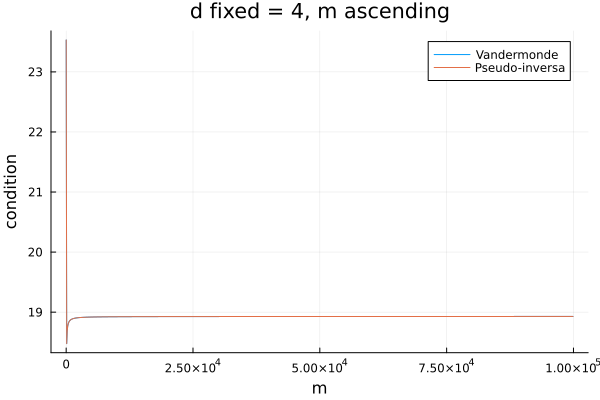

In [90]:
plot_condition_evaluated(100000, 4, variate_m= true, variate_d= false)


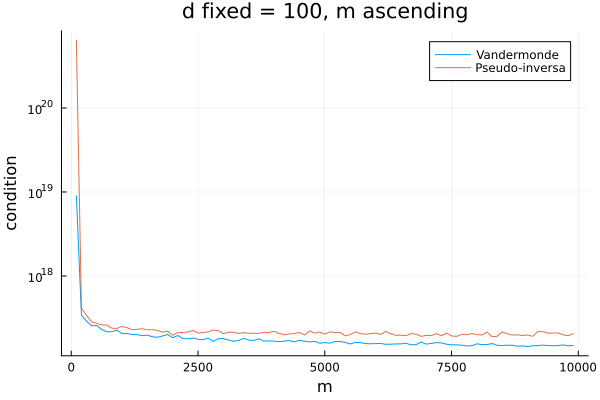

In [91]:
plot_condition_evaluated(10000, 100, variate_m= true, variate_d= false, logscale = true)

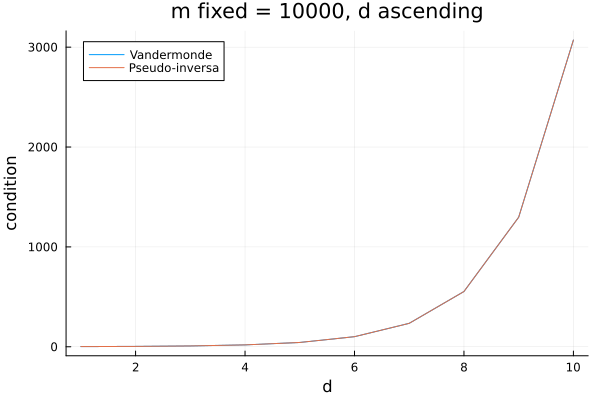

In [92]:
plot_condition_evaluated(10000, 10, variate_m= false, variate_d= true)

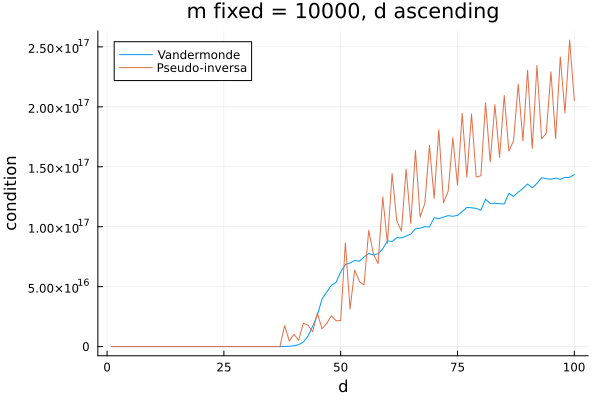

In [93]:
plot_condition_evaluated(10000, 100, variate_m= false, variate_d= true)


Podemos conferir que aumentar o número de pontos avaliados diminui o condicionamento até um ponto em que aparentemente ele atinge certa estabilidade. Portanto, o contrário também deve ser válido, aumentar o grau do nosso polinômio piora o condicionamento. 

### Letra e)

#### Calculando as Matrizes

Sabemos que a matriz de Vandermonde realiza a avalização de um polinômio da base canônica em um ponto $x_i$. Trocando da base cancônica para a base dos polinômios interpoladores de Lagrange, sabemos que 

$$p_i(x_j) = \delta_{ij},  \space \space 
 \delta{ij} =\begin{cases}
                1, i=j \\
                0, i \neq j
                \end{cases}
$$

Assim, ao avaliar um polinômio que é a combinação linear dos polinômios da base em um ponto $x_j$ (linha $j$), aparecerá apenas a parte do polinômio relacionada àquela linha. Logo, $L_X$ na base de Lagrange é

$$A =
\begin{bmatrix}
I_{d+1 \times d+1} \\ 0_{m - (d+1) \times d+1}
\end{bmatrix}

\Longrightarrow 

(L_X)_{ij} = \begin{cases}
                1, i=j \\
                0, i \neq j
                \end{cases}
$$

* Essa base foi calculada com $p_i(x) = \prod_{\substack{j=0 \\ j \neq i}}^{n} \frac{x - x_j}{x_i - x_j}$, fazendo com que não tivesse lixo, diferente da interpolação utilizada para provar que $L_X$ tem posto completo.

Assim, $R_X,d$ nessa nova base tem a mesma fórmula que na base antiga $R_{X,d}(b) = (A^TA)^{-1}A^Tb$. Portanto, 

$$ (A^TA)^{-1}A^T = \begin{bmatrix}
I_{(d+1) \times (d+1)} \space \space 0_{(d+1) \times m - (d+1)}
\end{bmatrix}$$

#### Condicionamento

Sabemos que os valores singulares de uma matriz $A$ são iguais a raiz dos autovalores de $A^TA$. Dessa forma, $$A^TA = \begin{bmatrix}
I_{(d+1) \times (d+1)} \space \space 0_{(d+1) \times m - (d+1)}
\end{bmatrix}\begin{bmatrix}
I_{d+1 \times d+1} \\ 0_{m - (d+1) \times d+1}
\end{bmatrix} = \begin{bmatrix}
I_{d+1 \times d+1} 
\end{bmatrix}$$

Como seus autovalores são $1$, então os valores singulares de $A$ são também iguais a $1$ e, portanto, o condicionamento da matriz $A$

$$\kappa (A) = \kappa(A^+) = 1$$

Assim, o condicionamento de $L_X$ e $R_{X,d}$ na base dos polinômios de Lagrange é igual a $1$.

### Letra f)

#### Base Canônica
Para calcular $L_X$ na base canônica, ou seja, para calcular a matriz de Vandermonde é necessário para cada linha $d - 1$ multiplicações para encontrarmos cada entrada, assim, para as $m$ linhas, nós encontramos uma complexidade $O(md)$.

#### Base de Lagrange
Nós podemos usar do fato de que nós já conhecemos a contrução de ambas as matrizes $L_X$ e $R_{X,d}$, respectivamente:

$$\begin{bmatrix}
I_{d+1 \times d+1} \\ 0_{m - (d+1) \times d+1}
\end{bmatrix}
\space \space \space \space \space \space\space \space \space
\begin{bmatrix}
I_{(d+1) \times (d+1)} \space \space 0_{(d+1) \times m - (d+1)}
\end{bmatrix}
$$

Portanto, a complexidade para calcular ambas é $O(1)$. Assim como o condicionamento dessas matrizes é $\kappa = 1$.

## Questão 3 )

### Letra a )

Sabemos que $R_{X_d}: \mathbb{R}^m \rightarrow \mathcal{P}_d$, $R_{X,d} \circ L_X = id_{\mathcal{P}_d}$, o que significa que para todo $p \in \mathcal{P}_d$ existe um vetor $b = L_X(p) \in \mathbb{R}^m$ tal que $R_{X,d}(b) = p$. Portanto, $R_{X,d}$ é sobrejetora e $Im(R_{X,d}) = \mathcal{P}_d$, o que implica que o posto de $R_{X,d}$ é $dim(Im(R_{X,d})) = d+1$.

Sabemos também que $L_Y$ tem posto completo e, logo, seu posto é $\min \lbrace n, d+ 1 \rbrace$

Além disso, sabemos que a transformação $(L_Y \circ R_{X,d})(b)$ é definida como $LY(R_{X,d}(b))$, e, portanto, a entrada de $L_Y$ é a saída de $R_{X,d}$, o que implica que quem vai determinar o posto da transformação é $L_Y$. Logo, o posto da transformação é $\min \lbrace n, d+ 1 \rbrace$.



### Letra b )



### Letra c )

Vamos voltar a definição do funcional de avaliação, quando restrito ao $\mathcal{P}_d$, 

$$ L_X: \mathbb{R}^m \rightarrow \mathcal{P}_d, \space \space \space \space L_X(p) = ( p(x_1) , \dots , p(x_m))$$

Dessa forma, ao tomarmos $b \in \mathbb{R}^m$ e aplicarmos $R_{X,d}(b) = p$, essa transformação nos retorna o melhor polinômio $p$ que nos retorna $p(x_i) = b_i$. Ao aplicarmos, $L_Y$ sobre o nosso polinômio resultante $p$, então nós obtemos $L_Y(p) = (p(y_1), \dots , p(y_n))$. Ou seja, nós avaliamos os valores de $Y$ no polinômio $p$ no mesmo intervalo conhecido $[-1,1]$. Ou seja, nós interpolamos $Y$ no polinômio $p$.

### Letra d )

In [94]:
function createLagrange(X, Y, d)
    nodes = X[1:d+1]
    n = length(Y)
    L = zeros(n, d+1)

    for i in 1:(d+1)
        denominador = prod((nodes[i] - nodes[k]) for k in 1:(d+1) if k != i)
        for j in 1:n
            numerador = prod((Y[j] - nodes[k]) for k in 1:(d+1) if k != i)
            L[j, i] = numerador / denominador
        end
    end
    return L
end

createLagrange (generic function with 1 method)

In [107]:
function compare_bases(m, n, d; Chebyshev= false)
    if Chebyshev
        X = [cos((2i - 1) / (2m) * π) for i in 1:m] 
    else
        X = LinRange(-1, 1, m)
    end

    Y = LinRange(-1, 1, n)

    L = createLagrange(X, Y ,d) * pinv(createLagrange(X, X ,d))
    C = createVandermonde(Y,d) * pinv(createVandermonde(X,d))
    
    return L, C, svdvals(L), svdvals(C)
end

compare_bases (generic function with 2 methods)

1) $m = d + 1$

In [197]:
L, C, sigmaL, sigmaC = compare_bases(11,60,10)
println("Valores Singulares Lagrange: ", sigmaL)
println("Valores Singulares Canônica: ", sigmaC)

plot(1:60, sigmaL)

Valores Singulares Lagrange: [26.789495798412425, 8.579624741639533, 2.470590390695675, 2.4357359752244756, 2.428991954845508, 2.4289638307846393, 2.4286235395578264, 2.238920418865307, 2.0821700737848774, 1.0842074288468289, 1.055919398996161]
Valores Singulares Canônica: [26.789495798401692, 8.579624741640034, 2.470590390695807, 2.435735975224501, 2.428991954845519, 2.428963830784641, 2.4286235395577864, 2.2389204188653213, 2.082170073784815, 1.0842074288468388, 1.055919398996123]


print device already activated
print device already activated
print device already activated


In [ ]:
L, C, sigmaL, sigmaC = compare_bases(51,30,50)
println("Valores Singulares Lagrange: ", sigmaL)
println("Valores Singulares Canônica: ", sigmaC)

Valores Singulares Lagrange: [8.896222719011013e9, 9.842116675580368e8, 340759.88190106937, 74446.96834055461, 112.2682098847682, 38.09167978120372, 1.5435190286382343, 1.263520832671858, 1.0778965644902458, 1.0771763913643997, 1.0770324872863093, 1.0770291173144386, 1.0738068882852267, 1.0724580243190018, 1.0339922254811589, 1.01697518966911, 1.0000000000000002, 1.0, 0.7620891313440661, 0.7616936797568064, 0.7615774018573378, 0.7615773114093025, 0.7615773105864148, 0.7615773105863982, 0.7615773105863923, 0.7615773105863904, 0.76157731058639, 0.7615773105856738, 0.7615773105254027, 0.7615764886148203]
Valores Singulares Canônica: [9522.704312311867, 3889.9371693987105, 12.713802011770056, 7.0942396203676, 1.0967790765326149, 1.0740509364675344, 1.0000002213642432, 1.0000001204699733, 0.9403408153676925, 0.9320243736567376, 0.7956745785377637, 0.7693793911788477, 0.7616397050462143, 0.7615849314500642, 0.7615774286742576, 0.7615773607399252, 0.7615773136542392, 0.7615773107459944, 0.761

30-element Vector{Float64}:
 9522.704312311867
 3889.9371693987105
   12.713802011770056
    7.0942396203676
    1.0967790765326149
    1.0740509364675344
    1.0000002213642432
    1.0000001204699733
    0.9403408153676925
    0.9320243736567376
    ⋮
    0.7615772999333943
    0.7615772863948367
    0.7615771005274916
    0.7615761529472879
    0.7612528807504138
    0.7595303942369505
    0.6510312644304033
    0.4343470509237941
    0.026127324754526293

2) $m \geq d + 1$

In [190]:
L, C, sigmaL, sigmaC = compare_bases(500,30,10)
println("Valores Singulares Lagrange: ", round.(sigmaL, digits = 5))
println("Valores Singulares Canônica: ", round.(sigmaC, digits = 5))

Valores Singulares Lagrange: [0.4109, 0.24109, 0.24108, 0.24107, 0.23675, 2.0e-5, 1.0e-5, 1.0e-5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Valores Singulares Canônica: [0.49116, 0.45435, 0.24132, 0.24117, 0.24107, 0.24107, 0.24107, 0.24107, 0.24107, 0.23215, 0.22528, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


Podemos perceber que, assim como nós descobrimos na letra b, a composta não depende da base, mas nossas matrizes se tornam diferentes a medida que aumentamos o grau do nosso polinômio.

## Questão e )

In [ ]:
function plot_condition_evaluated_bases(m, n, d; variate_n = true, variate_d = false, logscale= false, lim_x = (-1,1), lim_y= (-1,1))
    x1, x2 = lim_x
    y1, y2 = lim_y

    X = LinRange(x1, x2, m)

    if variate_n && !variate_d
        data_l = Float64[]
        data_c = Float64[]

        range = (d+1):n
        for i in range
            Y = LinRange(y1, y2, i)
            push!(data_l, cond(createLagrange(X, Y ,d) * pinv(createLagrange(X, X ,d))))
            push!(data_c, cond(createVandermonde(Y,d) * pinv(createVandermonde(X,d))))
        end

        p = plot(range, data_l, xlabel= "n: #Y", ylabel= "condition", title= "d fixed = $d, n ascending", label= "Lagrange")
        plot!(p, range, data_c, xlabel= "n: #Y", ylabel= "condition", title= "d fixed = $d, n ascending", label= "Canônica")

        if logscale
            plot!(p, yscale= :log10)
        end

        display(p)
        
    elseif !variate_n && variate_d
        data_l = Float64[]
        data_c = Float64[]

        range = 1:d
        for i in range
            Y = LinRange(y1, y2, m)
            push!(data_l, cond(createLagrange(X, Y ,i) * pinv(createLagrange(X, X ,i))))
            push!(data_c, cond(createVandermonde(Y,i) * pinv(createVandermonde(X,i))))
        end

        p = plot(range, data_l, label="Lagrange", xlabel= "d", ylabel= "condition", title= "n fixed = $n, d ascending")
        plot!(p, range, data_c, label= "Canônica", xlabel= "d", ylabel= "condition", title= "n fixed = $n, d ascending")

        if logscale
            plot!(p, yscale= :log10)
        end

        display(p)
    end
end

function plot_interpolation(m, n, d; Chebyshev= false, lim_x = (-1,1), lim_y = (-1,1))
    x1, x2 = lim_x
    y1, y2 = lim_y

    if Chebyshev
        X = [cos((2i - 1) / (2m) * π) for i in 1:m] 
    else
        X = LinRange(x1, x2, m)
    end

    Y = LinRange(y1, y2, n)
    t = cos.(3 .* X) .+ sin.(6 .* X)

    y_prev_ = createLagrange(X, Y, d) * pinv(createLagrange(X, X, d)) * t
    y_prev = createVandermonde(Y,d) * pinv(createVandermonde(X,d)) * t

    plot(X, t, label="f(x) original", size= (800,300), leg= :bottom, layout= (1,2))
    scatter!(Y, y_prev_, label="interpolado em Y", title= "Lagrange", subplot= 1)

    plot!(X, t, label="f(x) original", size= (800,300), leg= :bottom, subplot= 2)
    scatter!(Y, y_prev, label="interpolado em Y", title= "Canônica", subplot= 2)
end

plot_interpolation (generic function with 2 methods)

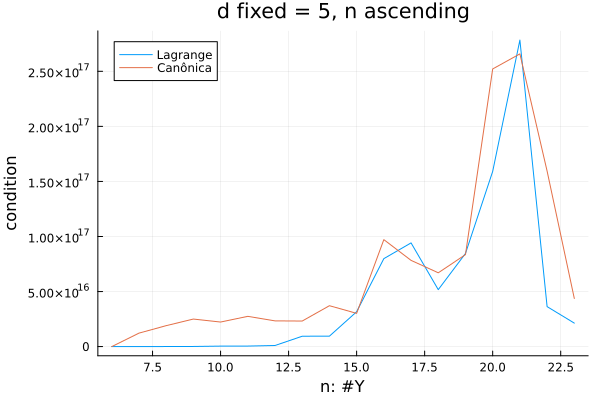

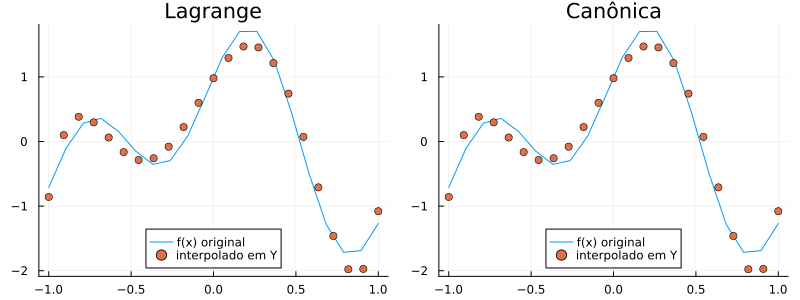

In [100]:
plot_condition_evaluated_bases(20, 23, 5, true, false)
plot_interpolation(20, 23, 5)

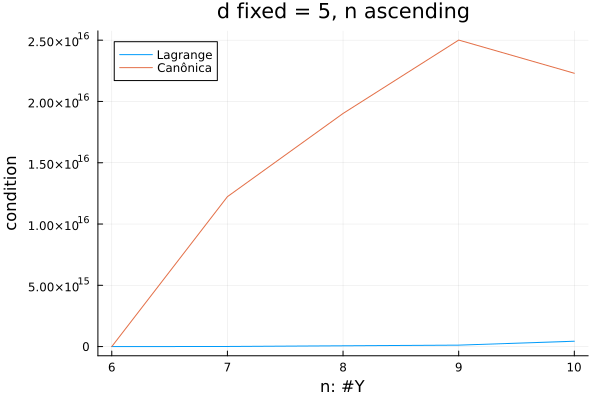

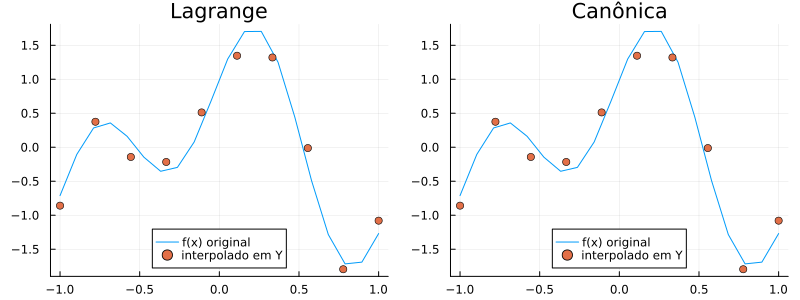

In [133]:
plot_condition_evaluated_bases(20, 10, 5, true, false)
plot_interpolation(20, 10, 5)

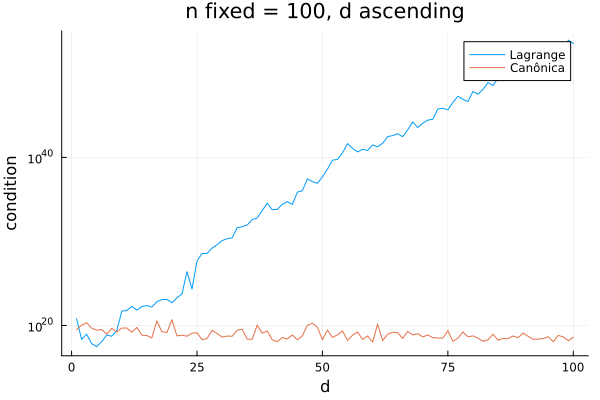

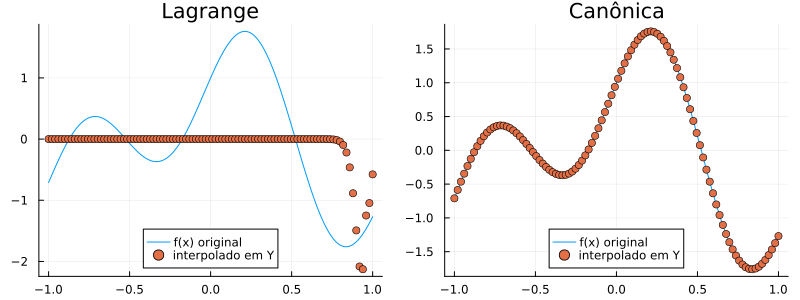

In [101]:
plot_condition_evaluated_bases(500, 100, 100, false, true, logscale= true)
plot_interpolation(500, 100, 100)

## Questão f )

In [145]:
L, C, sigmaL, sigmaC = compare_bases(20, 30, 5)
println("Valores Singulares Lagrange: ", round.(sigmaL, digits = 5))
println("Valores Singulares Canônica: ", round.(sigmaC, digits = 5))


Valores Singulares Lagrange: [1.24107, 1.23729, 1.23544, 1.23543, 1.10991, 1.07712, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Valores Singulares Canônica: [1.24107, 1.23729, 1.23544, 1.23543, 1.10991, 1.07712, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


In [146]:
L, C, sigmaL, sigmaC = compare_bases(100, 300, 10, Chebyshev= true)
println("Valores Singulares Lagrange: ", round.(sigmaL, digits = 5))
println("Valores Singulares Canônica: ", round.(sigmaC, digits = 5))

Valores Singulares Lagrange: [2.14977, 2.05748, 1.8297, 1.44607, 0.81625, 0.00014, 0.00012, 0.00012, 0.00011, 0.0001, 0.0001, 9.0e-5, 8.0e-5, 8.0e-5, 7.0e-5, 7.0e-5, 6.0e-5, 6.0e-5, 6.0e-5, 5.0e-5, 5.0e-5, 5.0e-5, 4.0e-5, 4.0e-5, 4.0e-5, 4.0e-5, 4.0e-5, 3.0e-5, 3.0e-5, 3.0e-5, 3.0e-5, 2.0e-5, 2.0e-5, 2.0e-5, 2.0e-5, 2.0e-5, 2.0e-5, 2.0e-5, 2.0e-5, 2.0e-5, 2.0e-5, 1.0e-5, 1.0e-5, 1.0e-5, 1.0e-5, 1.0e-5, 1.0e-5, 1.0e-5, 1.0e-5, 1.0e-5, 1.0e-5, 1.0e-5, 1.0e-5, 1.0e-5, 1.0e-5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Valores Singulares Canônica: [2.15761, 2.12134, 2.08044, 1.98145, 1.92262, 1.73824, 1.67428, 1.36439, 1.30856, 0.7818, 0.75982, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,

## Letra g )

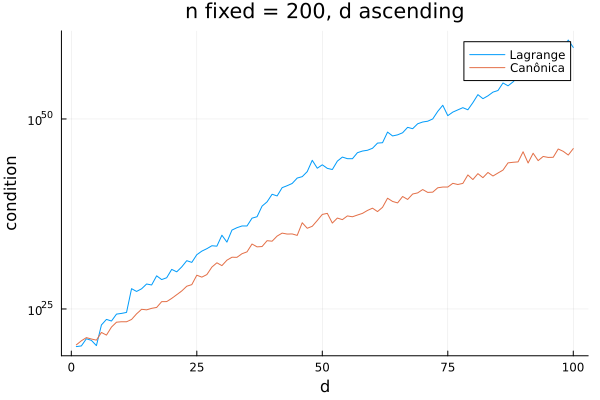

In [103]:
plot_condition_evaluated_bases(1000, 200, 100, false, true, logscale= true, lim_y= (-1.5,1.5))

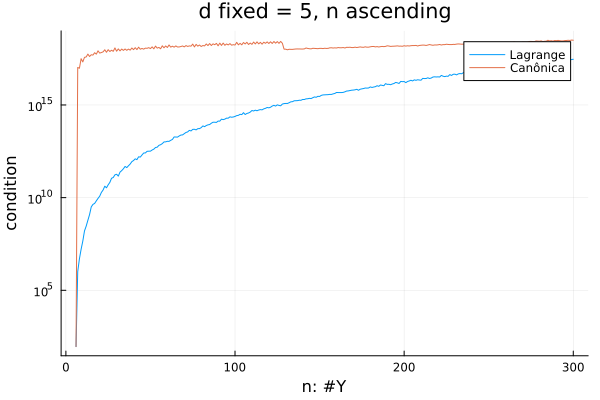

In [104]:
plot_condition_evaluated_bases(500, 300, 5, true, false, logscale= true, lim_y = (-1.5,1.5))

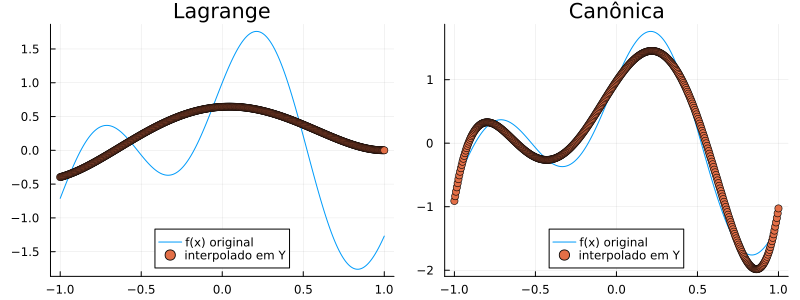

In [105]:
plot_interpolation(300, 400, 5, true)

## Letra h )

## Letra i )

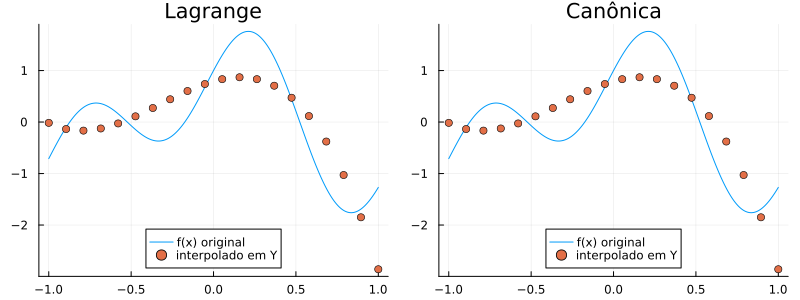

In [106]:
plot_interpolation(300, 20, 3)